Solving churn modelling using ANN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#ml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import accuracy_score
#tensorFlow and keras for dl
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
#loading dataset
df=pd.read_csv('Churn_Modelling.csv')
df.head()
print(df.shape)
print(df.info())
print(df.describe())


(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId  ...  EstimatedSalary        Exited
count  1

In [ ]:
#select i/p o/p
x=df.iloc[:, 3:-1]
y=df.iloc[:, -1]
print(x.head ())
print(y.head ())

   CreditScore Geography  Gender  ...  HasCrCard  IsActiveMember  EstimatedSalary
0          619    France  Female  ...          1               1        101348.88
1          608     Spain  Female  ...          0               1        112542.58
2          502    France  Female  ...          1               0        113931.57
3          699    France  Female  ...          0               0         93826.63
4          850     Spain  Female  ...          1               1         79084.10

[5 rows x 10 columns]
0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64


In [ ]:
#data preprocessing
from sklearn.preprocessing import LabelEncoder
gender_encoder = LabelEncoder()
geography_encoder = LabelEncoder()
x['Gender'] = gender_encoder.fit_transform(x['Gender'])
x['Geography'] = geography_encoder.fit_transform(x['Geography'])
print(x.head())

   CreditScore  Geography  Gender  ...  HasCrCard  IsActiveMember  EstimatedSalary
0          619          0       0  ...          1               1        101348.88
1          608          2       0  ...          0               1        112542.58
2          502          0       0  ...          1               0        113931.57
3          699          0       0  ...          0               0         93826.63
4          850          2       0  ...          1               1         79084.10

[5 rows x 10 columns]


In [ ]:
#train test split of data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 10)
(2000, 10)
(8000,)
(2000,)


In [ ]:
#featuring scaling
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [ ]:
#building of ANN
ann = Sequential()
ann.add(Dense(units=6, activation='relu')) #unit represents the no. of perceptron; input
ann.add(Dense(units=6, activation='relu')) # hidden layer
ann.add(Dense(units=1, activation='sigmoid')) # o/p layer

In [ ]:
#compile model
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#train
history=ann.fit(x_train, y_train, batch_size=32, epochs=100, validation_split=0.20)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7914 - loss: 0.5307 - val_accuracy: 0.7987 - val_loss: 0.4840
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4753 - val_accuracy: 0.7987 - val_loss: 0.4639
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4601 - val_accuracy: 0.7987 - val_loss: 0.4527
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4504 - val_accuracy: 0.7987 - val_loss: 0.4444
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4440 - val_accuracy: 0.7987 - val_loss: 0.4393
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4391 - val_accuracy: 0.7987 - val_loss: 0.4350
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4355 - val_accuracy: 0.7987 - val_loss: 0.4314
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4320 - val_accu

In [ ]:
#prediction
y_pred = ann.predict(x_test)
y_pred = (y_pred > 0.5)
print(y_pred [0:10])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]]


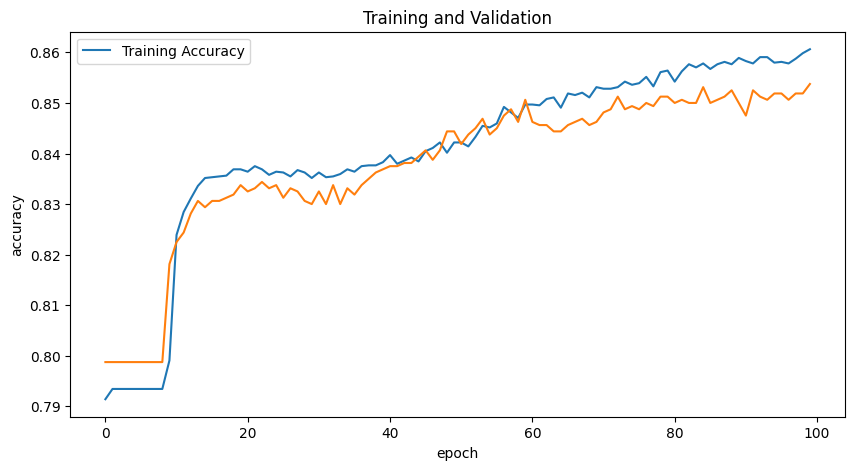

In [ ]:
#accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'])
plt.title('Training and Validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

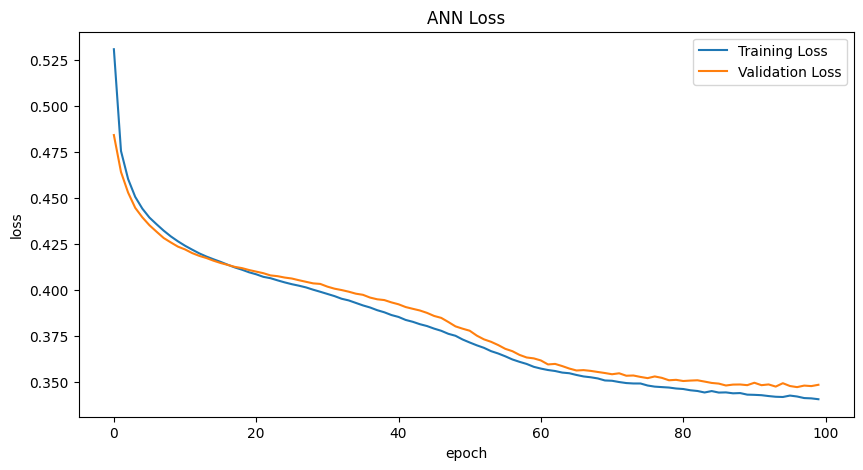

In [ ]:
#loss graph
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()